# Training and evaluating TCRStructMap_Sequence_Only

In [1]:
import itertools
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
with open('data/logs/train_tcr_struct_map_sequence_only.log') as fh:
    training_log = fh.read()

In [3]:
lines = [(i, line) for i, line in enumerate(training_log.split('\n')) if line]

In [4]:
fold_pattern = re.compile(r'(\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d,\d\d\d) - INFO: Starting fold (\d+)')
folds = [
    (
        i,
        pd.to_datetime(re.match(fold_pattern, line).group(1), format='%Y-%m-%d %H:%M:%S,%f'),
        int(re.match(fold_pattern, line).group(2)),
    )
    for i, line in lines
    if re.match(fold_pattern, line)
]

In [5]:
epoch_pattern = re.compile(r'(\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d,\d\d\d) - INFO: Starting epoch (\d+)')
epochs = [
    (
        i,
        pd.to_datetime(re.match(epoch_pattern, line).group(1), format='%Y-%m-%d %H:%M:%S,%f'),
        int(re.match(epoch_pattern, line).group(2)),
    )
    for i, line in lines
    if re.match(epoch_pattern, line)
]

In [6]:
evaluation_pattern = re.compile(r'(\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d,\d\d\d) - INFO: Evaluating at iteration (\d+)')
evaluation_steps = [
    (
        i,
        pd.to_datetime(re.match(evaluation_pattern, line).group(1), format='%Y-%m-%d %H:%M:%S,%f'),
        int(re.match(evaluation_pattern, line).group(2)),
    )
    for i, line in lines
    if re.match(evaluation_pattern, line)
]

In [7]:
loss_pattern = re.compile(r'\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d,\d\d\d - INFO: Loss: (\d+\.\d+)')
losses = [float(re.match(loss_pattern, line).group(1)) for _, line in lines if re.match(loss_pattern, line)]

In [8]:
training_roc_auc_pattern = re.compile(
    r'\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d,\d\d\d - INFO: Training ROC-AUC: (\d+\.\d+|nan)',
)
training_roc_aucs = [
    float(re.match(training_roc_auc_pattern, line).group(1))
    for _, line in lines
    if re.match(training_roc_auc_pattern, line)
]

In [ ]:
validation_roc_auc_pattern = re.compile(
    r'\d\d\d\d-\d\d-\d\d \d\d:\d\d:\d\d,\d\d\d - INFO: Validation ROC-AUC: (\d+\.\d+)',
)

validation_roc_aucs = [
    float(re.match(validation_roc_auc_pattern, line).group(1))
    for _, line in lines
    if re.match(validation_roc_auc_pattern, line)
]

In [10]:
folds_expanded = []
for idx, _, _ in evaluation_steps:
    for (fold_start_idx, _, fold), (fold_end_idx, _, _) in itertools.pairwise([*folds, (np.inf, _, _)]):  # noqa: B020
        if idx > fold_start_idx and idx < fold_end_idx:
            folds_expanded.append(fold)
            break

In [11]:
epochs_expanded = []
for idx, _, _ in evaluation_steps:
    for (epoch_start_idx, _, epoch), (epoch_end_idx, _, _) in itertools.pairwise([*epochs, (np.inf, _, _)]):  # noqa: B020
        if idx > epoch_start_idx and idx < epoch_end_idx:
            epochs_expanded.append(epoch)
            break

In [ ]:
training_log_df = pd.DataFrame(
    {
        'time': [time for _, time, _ in evaluation_steps],
        'fold': folds_expanded,
        'epoch': epochs_expanded,
        'training_step': [step for _, _, step in evaluation_steps],
        'loss': losses,
        'training_roc_auc': training_roc_aucs,
        'validation_roc_auc': validation_roc_aucs,
    }
)

In [13]:
training_log_df['relative_training_step'] = training_log_df.groupby('fold').cumcount() + 1

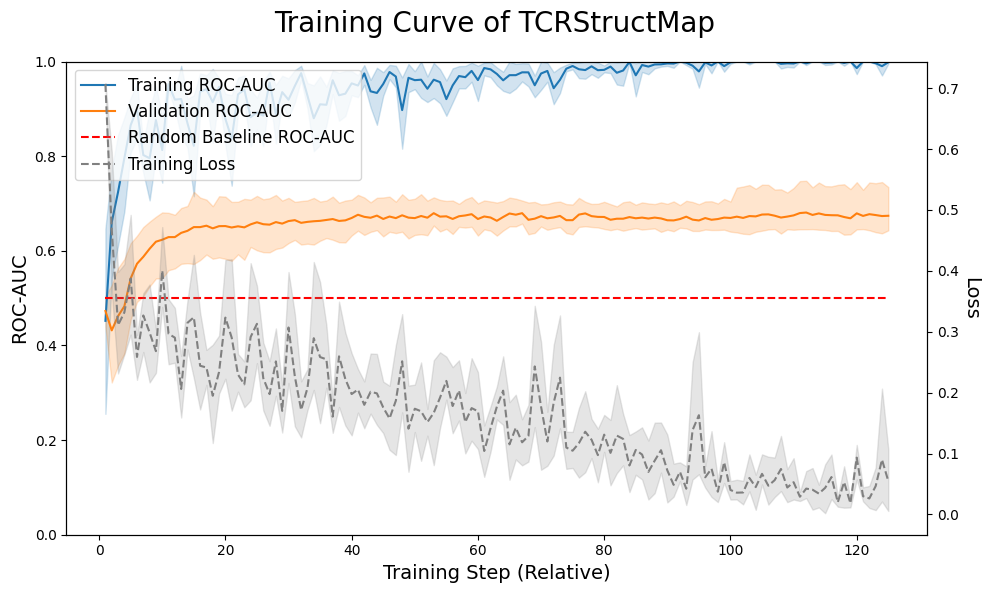

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 6))

fig.suptitle('Training Curve of TCRStructMap', fontsize=20)

sns.lineplot(training_log_df, x='relative_training_step', y='training_roc_auc', label='Training ROC-AUC', ax=ax1)
sns.lineplot(training_log_df, x='relative_training_step', y='validation_roc_auc', label='Validation ROC-AUC', ax=ax1)

ax1.axhline(
    0.5,
    xmin=(training_log_df['relative_training_step'].min() - ax1.get_xlim()[0])
    / (ax1.get_xlim()[1] - ax1.get_xlim()[0]),
    xmax=(training_log_df['relative_training_step'].max() - ax1.get_xlim()[0])
    / (ax1.get_xlim()[1] - ax1.get_xlim()[0]),
    color='r',
    linestyle='dashed',
    label='Random Baseline ROC-AUC',
)

ax1.set_xlabel('Training Step (Relative)', fontsize=14)
ax1.set_ylabel('ROC-AUC', fontsize=14)
ax1.set_ylim(0, 1.0)

ax2 = ax1.twinx()
sns.lineplot(
    training_log_df,
    x='relative_training_step',
    y='loss',
    color='grey',
    linestyle='--',
    label='Training Loss',
    legend=False,
    ax=ax2,
)

ax2.set_ylabel('Loss', fontsize=14, rotation=270, labelpad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()